In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
base_path = "../data/preprocessed/processed_data.xlsx"
df=pd.read_excel(base_path)

In [3]:
df.set_index('Date',inplace=True)

In [4]:
monthly_data=df.copy()

monthly_data=monthly_data.resample('ME').mean()
monthly_data['Low Carbon Percentage']=monthly_data['Low Carbon Percentage']/100
monthly_data['Renewable Percentage']=monthly_data['Renewable Percentage']/100

In [5]:
monthly_data.head()

,Carbon Intensity gCO₂eq/kWh (LCA),Carbon Intensity gCO₂eq/kWh (direct),Low Carbon Percentage,Renewable Percentage,End user energy consumtion(KWH),Total energy production Swiss controlblock(KWH),Total energy consumption Swiss controlblock(KWH),Grid feed-in Swiss transmission grid(KWH),Net outflow of the Swiss transmission grid(KWH)
Date,,,,,,,,,
2021-01-31,145.750591,112.814194,0.859489,0.496341,7.551365e+06,7.544712e+06,8.397672e+06,5.736536e+06,1.266360e+06
2021-02-28,107.157738,77.353839,0.895951,0.490586,7.230775e+06,7.415168e+06,7.999966e+06,5.215081e+06,9.329799e+05
2021-03-31,110.366492,80.857796,0.894485,0.458673,6.876897e+06,7.046545e+06,7.575984e+06,4.999623e+06,9.165894e+05
2021-04-30,110.835236,78.926653,0.899390,0.480366,6.304954e+06,6.658315e+06,7.098627e+06,4.496147e+06,7.207859e+05
2021-05-31,70.380484,41.093602,0.944119,0.603885,5.964784e+06,6.990286e+06,6.972034e+06,4.367743e+06,6.982312e+05


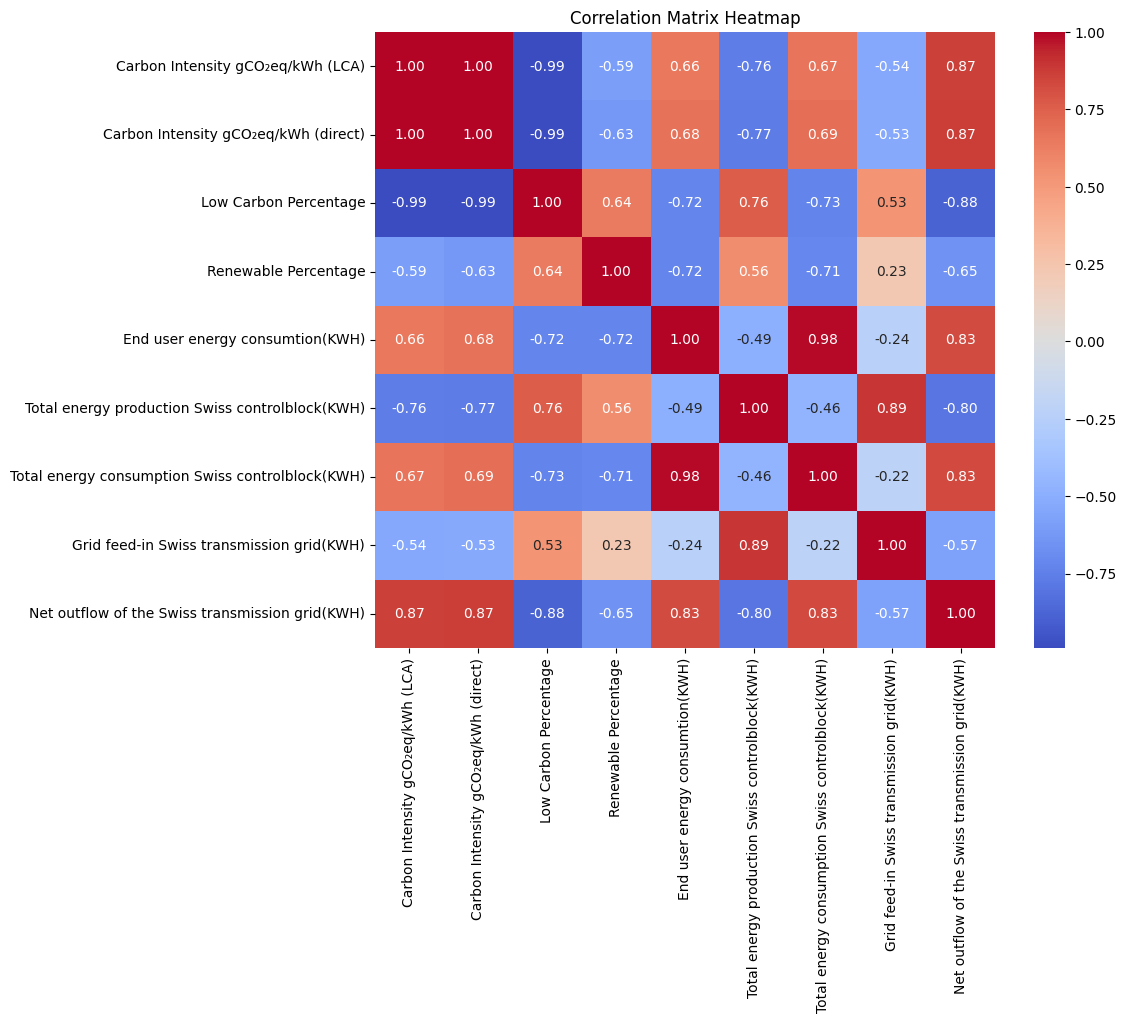

In [6]:


# Calculate the correlation matrix
correlation_matrix = monthly_data.corr()

# Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()





In [7]:
#split data

train_data=monthly_data['2021':'2022']
test_data=monthly_data['2023':]
#exogeneous variables
exog_train = train_data[[ 'Total energy production Swiss controlblock(KWH)',
                         'Total energy consumption Swiss controlblock(KWH)',
                         'Renewable Percentage',
                         'Low Carbon Percentage',
                         'Grid feed-in Swiss transmission grid(KWH)',
                         'Net outflow of the Swiss transmission grid(KWH)',
                         'End user energy consumtion(KWH)'
                        ]
                         ]
exog_test = test_data[[ 'Total energy consumption Swiss controlblock(KWH)',
                       'Total energy consumption Swiss controlblock(KWH)',
                       'Renewable Percentage',
                       'Low Carbon Percentage',
                       'Grid feed-in Swiss transmission grid(KWH)',
                       'Net outflow of the Swiss transmission grid(KWH)',
                       'End user energy consumtion(KWH)'
                       ]]
#Target Variable
y_train = train_data['Carbon Intensity gCO₂eq/kWh (LCA)']  # Target variable for training
y_test = test_data['Carbon Intensity gCO₂eq/kWh (LCA)']

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#define SARIMA parameters for monthly data
sarima_order_monthly=(0,0,1)
seasonal_order_monthly=(0,1,0,12)

#fit the model
sarima_monthly_model=SARIMAX(
    y_train,
    exog=exog_train,
    order=sarima_order_monthly,
    seasonal_order=seasonal_order_monthly,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=5000,method='powell' )
#method='cg'

In [9]:
#predict
predict=sarima_monthly_model.forecast(steps=len(y_test),exog=exog_test)


In [10]:
#evaluate
mae=mean_absolute_error(y_test,predict)
mse=mean_squared_error(y_test,predict)
rmse=np.sqrt(mse)
mape=np.mean(np.abs(y_test-predict)/y_test) * 100

print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae}")
print(f"mean squared error :  {mse}")
print(f"Root mean squared error :  {rmse}")

print(f"mean absolute percentage error :  {mape}")


The metrics for the Sarima model

mean absolute error :  22.393535534006855
mean squared error :  651.2322375583793
Root mean squared error :  25.51925229230628
mean absolute percentage error :  30.995510545507482


In [11]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Forecast': predict,
    'difference':abs(y_test-predict)
})
comparison

,Actual,Forecast,difference
2023-01-31,131.339073,141.459637,10.120564
2023-02-28,150.613765,167.704306,17.090542
2023-03-31,100.541398,96.666633,3.874764
2023-04-30,91.049694,88.138800,2.910894
2023-05-31,69.528952,57.323787,12.205165
2023-06-30,66.086639,31.276707,34.809932
2023-07-31,64.695349,31.734743,32.960606
2023-08-31,63.406142,28.375198,35.030945
2023-09-30,61.974389,37.567925,24.406463
2023-10-31,62.964355,30.533206,32.431149


<Axes: >

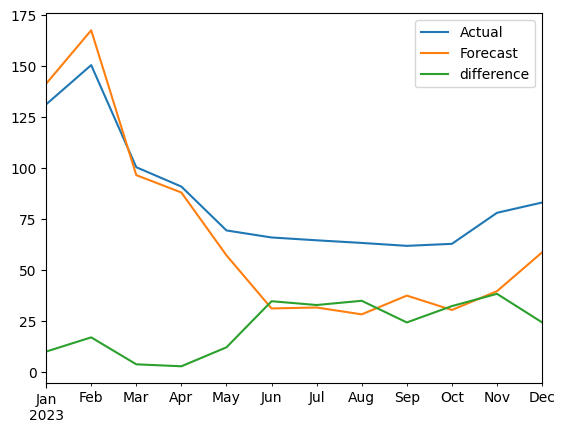

In [12]:
comparison.plot()

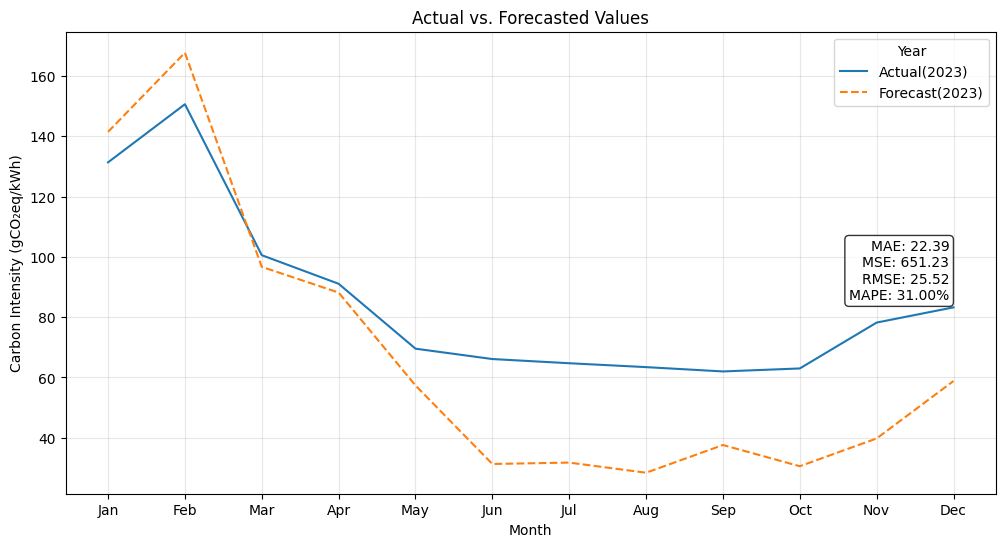

In [13]:

plt.figure(figsize=(12, 6))
plt.plot(y_test.index.month,y_test, label='Actual(2023)')
plt.plot(y_test.index.month,predict, label='Forecast(2023)', linestyle='--')
#title and label
plt.xlabel("Month")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.xticks(range(1, 13), [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=10)
plt.legend(title="Year", fontsize=10)
plt.grid(alpha=0.3)
plt.title('Actual vs. Forecasted Values')

#metrics

metrics_text_predicted = (
    f"MAE: {mae:.2f}\n"
    f"MSE: {mse:.2f}\n"
    f"RMSE: {rmse:.2f}\n"
    f"MAPE: {mape:.2f}%"
)
plt.text(
    0.95, 0.55, metrics_text_predicted, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.show()


## saving tests on a txt file

In [14]:

exog_df=pd.DataFrame({'exogenous variables':exog_train.columns})
metrics_df=pd.DataFrame({'Metric': ['MAE', 'MSE'], 
                        'Value': [mae, mse]})
result=pd.concat([exog_df,metrics_df],axis=0)
output_file="exog_variables_metrics.csv"

if os.path.exists(output_file):
   
    result.to_csv(output_file, index=False, header=False, mode='a')
else:
    
    result.to_csv(output_file, index=False)

result

' \nexog_df=pd.DataFrame({\'exogenous variables\':exog_train.columns})\nmetrics_df=pd.DataFrame({\'Metric\': [\'MAE\', \'MSE\'], \n                        \'Value\': [mae, mse]})\nresult=pd.concat([exog_df,metrics_df],axis=0)\noutput_file="exog_variables_metrics.csv"\n\nif os.path.exists(output_file):\n   \n    result.to_csv(output_file, index=False, header=False, mode=\'a\')\nelse:\n    \n    result.to_csv(output_file, index=False)\n\nresult '